In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
np.random.seed(42)

months = np.arange(1, 25)  # 24 months of data
# Simulate an upward trend with some noise
revenue = 50000 + (months * 2500) + np.random.normal(0, 4000, 24)

df = pd.DataFrame({
    'Month_Number': months,
    'Revenue': revenue.round(0)
})

print(df)

    Month_Number   Revenue
0              1   54487.0
1              2   54447.0
2              3   60091.0
3              4   66092.0
4              5   61563.0
5              6   64063.0
6              7   73817.0
7              8   73070.0
8              9   70622.0
9             10   77170.0
10            11   75646.0
11            12   78137.0
12            13   83468.0
13            14   77347.0
14            15   80600.0
15            16   87751.0
16            17   88449.0
17            18   96257.0
18            19   93868.0
19            20   94351.0
20            21  108363.0
21            22  104097.0
22            23  107770.0
23            24  104301.0


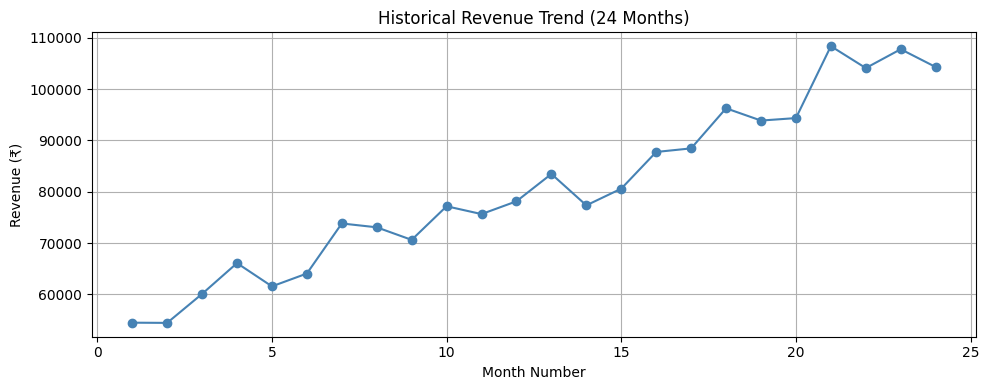

In [3]:
plt.figure(figsize=(10,4))
plt.plot(df['Month_Number'], df['Revenue'], marker='o', color='steelblue')
plt.title('Historical Revenue Trend (24 Months)')
plt.xlabel('Month Number')
plt.ylabel('Revenue (₹)')
plt.grid(True)
plt.tight_layout()
plt.savefig('historical_trend.png')
plt.show()

In [4]:
X = df[['Month_Number']]
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Coefficient (growth per month): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Model trained successfully!
Coefficient (growth per month): 2287.01
Intercept: 52463.57


In [5]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("====== MODEL EVALUATION ======")
print(f"Mean Absolute Error : ₹{mae:,.2f}")
print(f"RMSE                : ₹{rmse:,.2f}")
print(f"R² Score            : {r2:.3f}")

====== MODEL EVALUATION ======
Mean Absolute Error : ₹1,880.27
RMSE                : ₹2,081.09
R² Score            : 0.978


In [6]:
future_months = np.arange(25, 37).reshape(-1, 1)  # Next 12 months
future_pred = model.predict(future_months)

forecast_df = pd.DataFrame({
    'Month_Number': future_months.flatten(),
    'Predicted_Revenue': future_pred.round(0)
})
print(forecast_df)

    Month_Number  Predicted_Revenue
0             25           109639.0
1             26           111926.0
2             27           114213.0
3             28           116500.0
4             29           118787.0
5             30           121074.0
6             31           123361.0
7             32           125648.0
8             33           127935.0
9             34           130222.0
10            35           132509.0
11            36           134796.0


C:\Users\Sandhya\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


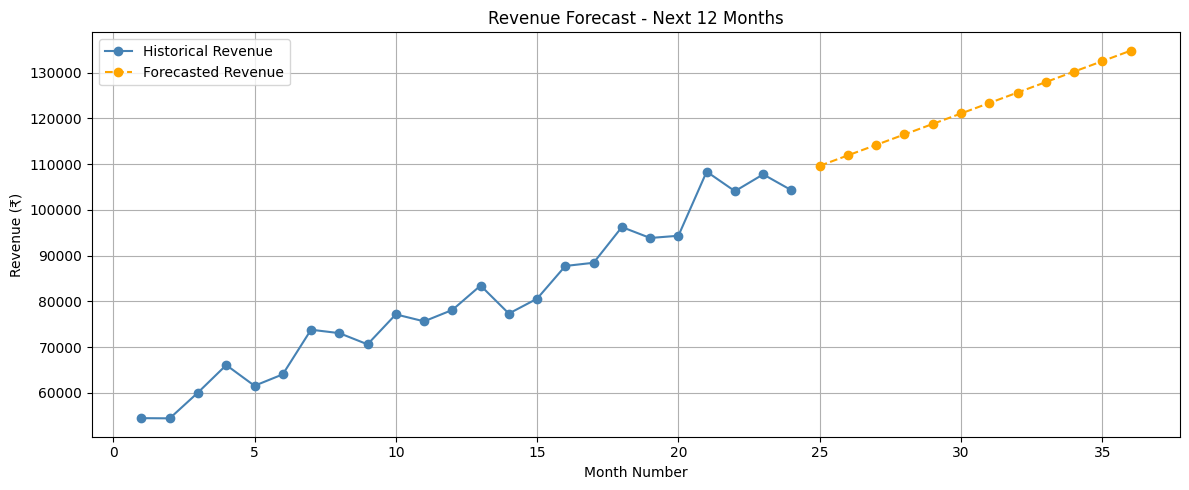

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['Month_Number'], df['Revenue'], marker='o', color='steelblue', label='Historical Revenue')
plt.plot(forecast_df['Month_Number'], forecast_df['Predicted_Revenue'], 
         marker='o', color='orange', linestyle='--', label='Forecasted Revenue')
plt.title('Revenue Forecast - Next 12 Months')
plt.xlabel('Month Number')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('forecast_chart.png')
plt.show()